In [1]:
import os

print(os.listdir())

['PV_ADR_anlyzer_.ipynb', 'pv_analysis.db', '.DS_Store', 'stock_dashboard.csv', 'Drug_Stock_Dashboard_.ipynb', 'drug_submmision.xlsx', 'ich_q1_stab_analy_np.ipynb', 'batch_qc.db', 'QC_intelligent_system_.ipynb', 'ADR_Freq_Analyzer_.ipynb', 'Regl_Subm_Trak.ipynb', 'adr_data.csv', 'stability_numpy_report.txt', 'adr_trend.png', 'Drug_Stock_Dashboard_.py', 'adr.db', 'CDSCO_Drug_Approval_Database.ipynb', 'stock_dashboard.png', 'adr_bar.png']


In [2]:
import os

print(os.getcwd())

/Users/shashank/regulatory_pharma/py_data_toolkit


Index(['ID', 'Drug', 'Agency', 'Type', 'Status', 'Submitted', 'Deadline'], dtype='str')
  REGULATORY SUBMISSION TRACKER
             Drug  Agency   Type       Status   Deadline
 Metformin 500mg   CDSCO    NDA      Approved 2025-07-10
    Aspirin 75mg     FDA   ANDA       Pending 2025-09-15
 Insulin Glargine  CDSCO    NDA  Under Review 2025-10-20
    Atorvastatin     FDA    NDA      Approved 2025-08-05
     Amoxicillin   CDSCO   ANDA      Rejected 2025-11-01
    Warfarin 5mg     FDA    NDA       Pending 2026-12-10
     Paracetamol   CDSCO   ANDA  Under Review 2025-12-01
     Semaglutide     FDA    NDA       Pending 2025-11-20

--- Status Count ---
Status
Pending         3
Approved        2
Under Review    2
Rejected        1
Name: count, dtype: int64

--- Pending Submissions (3) ---
          Drug Agency   Deadline
 Aspirin 75mg    FDA  2025-09-15
  Semaglutide    FDA  2025-11-20
 Warfarin 5mg    FDA  2026-12-10

--- Deadline Urgency ---
             Drug       Status  Days_Remaining   

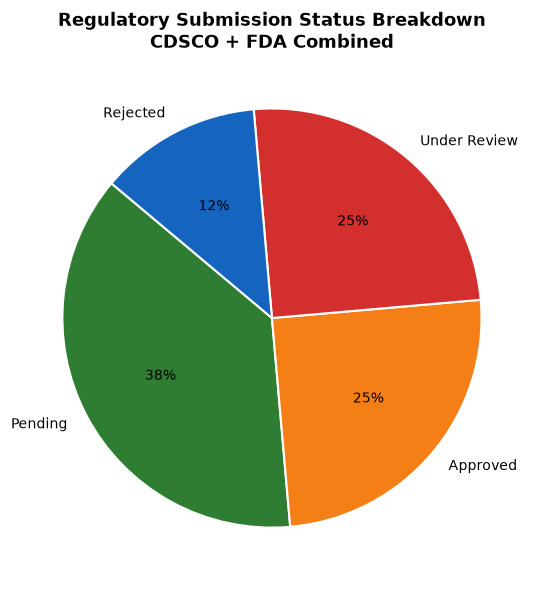

✅ submission_status.png saved


/var/folders/ll/jf0j17hd5vl4hsvyy49gbrxc0000gn/T/ipykernel_74943/2708698914.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Agency",


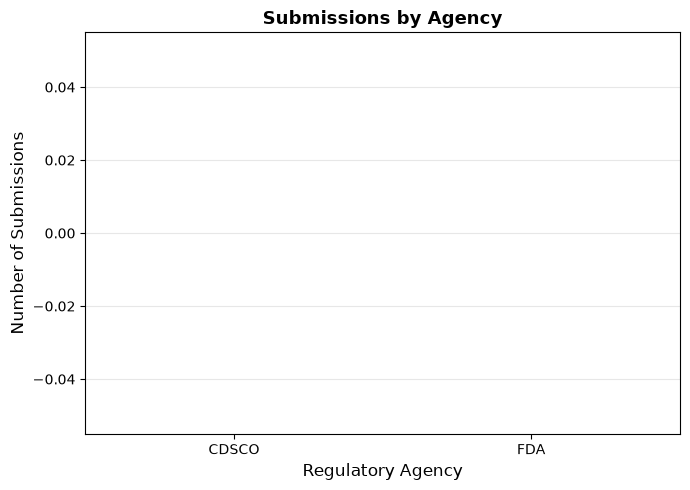

✅ agency_chart.png saved


In [36]:
import pandas as pd
from datetime import date
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("drug_submmision.xlsx")
df = pd.DataFrame(df)

df.columns = df.columns.str.strip()
df["Status"] = df["Status"].str.strip()

print(df.columns)
df["Submitted"] = pd.to_datetime(df["Submitted"])
df["Deadline"]  = pd.to_datetime(df["Deadline"])

print("=" * 60)
print("  REGULATORY SUBMISSION TRACKER")
print("=" * 60)
print(df[["Drug","Agency","Type","Status","Deadline"]]
      .to_string(index=False))

status_count = df["Status"].value_counts()
print("\n--- Status Count ---")
print(status_count)

pending = df[df["Status"] == "Pending"].sort_values("Deadline")
print(f"\n--- Pending Submissions ({len(pending)}) ---")
print(pending[["Drug","Agency","Deadline"]].to_string(index=False))

df["Days_Remaining"] = (
    df["Deadline"] - pd.Timestamp("today")
).dt.days

df["Priority"] = df["Days_Remaining"].apply(
    lambda x: "!!!! URGENT" if x < 180 else " OK"
)

print(f"\n--- Deadline Urgency ---")
print(df[["Drug","Status","Days_Remaining","Priority"]]
      .sort_values("Days_Remaining")
      .to_string(index=False))

colors_pie = ["#2e7d32","#f57f17","#d32f2f","#1565c0"]
plt.figure(figsize=(7, 6))
plt.pie(
    status_count.values,
    labels=status_count.index,
    autopct="%1.0f%%",
    colors=colors_pie,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
plt.title("Regulatory Submission Status Breakdown\n"
          "CDSCO + FDA Combined",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("submission_status.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("✅ submission_status.png saved")

# ── 6. AGENCY BAR CHART ──────────────────────────────
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Agency",
              palette=["#1565c0","#d32f2f"],
              order=["CDSCO","FDA"])
plt.title("Submissions by Agency",
          fontsize=13, fontweight="bold")
plt.xlabel("Regulatory Agency", fontsize=12)
plt.ylabel("Number of Submissions", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("agency_chart.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("✅ agency_chart.png saved")

